# Exploratory Data Analysis Notebook

This notebook contains the exploratory data analysis for the cleaned dynamic pricing ride-sharing dataset

## Import Libraries

Importing the libraries needed for data analysis and visualization

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os 

## Load Cleaned Dataset

Loading the cleaned dataset that was saved during the data cleaning step

In [8]:
cleaned_file_path = "../Data/Cleaned/cleaned_dynamic_pricing.csv"

df = pd.read_csv(cleaned_file_path)
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


## Dataset Overview

Checking the size of the cleaned dataset and reviewing the main summary statistics


In [10]:
df.shape

(1000, 10)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [12]:
df.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


The cleaned dataset contains 1000 rows and 10 columns. The dataset includes numerical variables related to demand, supply, customer history, ratings, ride duration, and historical ride cost

## Create New Columns for Analysis

The dataset does not include exact customer coordinates, driver coordinates, waiting time, or arrival time. Therefore, adding additional columns using the available variables to explore demand, supply, and pricing patterns

In [13]:
df["Demand_Supply_Ratio"] = df["Number_of_Riders"] / df["Number_of_Drivers"]

df["Demand_Supply_Difference"] = df["Number_of_Riders"] - df["Number_of_Drivers"]

df["Cost_per_Minute"] = df["Historical_Cost_of_Ride"] / df["Expected_Ride_Duration"]

df[["Demand_Supply_Ratio", "Demand_Supply_Difference", "Cost_per_Minute"]].head()

,Demand_Supply_Ratio,Demand_Supply_Difference,Cost_per_Minute
0,2.000000,45,3.158414
1,1.487179,19,4.043599
2,1.354839,11,4.339414
3,3.178571,61,3.508964
4,3.545455,56,3.890479


These new columns help analyze the relationship between demand, supply, and pricing. `Demand_Supply_Ratio` shows how many riders there are compared to available drivers. `Demand_Supply_Difference` shows the gap between riders and drivers. `Cost_per_Minute` helps compare ride prices while considering ride duration

## Summary of New Columns

In [14]:
df[["Demand_Supply_Ratio", "Demand_Supply_Difference", "Cost_per_Minute"]].describe()

,Demand_Supply_Ratio,Demand_Supply_Difference,Cost_per_Minute
count,1000.000000,1000.000000,1000.000000
mean,3.235461,33.296000,3.890068
std,2.533519,18.936869,0.912955
min,1.112360,10.000000,2.502595
25%,1.658793,18.000000,3.243703
50%,2.357143,28.000000,3.772418
75%,3.800000,45.250000,4.347651
max,17.600000,93.000000,8.889501


The summary of the new columns shows that demand is higher than supply in most cases, since the demand-supply ratio is above 1. The cost per minute column helps compare rides more fairly because longer rides usually have higher total costs

## Distribution of Historical Ride Cost

Examining the distribution of historical ride cost since this is the main pricing variable in the dataset

In [15]:
df["Historical_Cost_of_Ride"].describe()

count    1000.000000
mean      372.502623
std       187.158756
min        25.993449
25%       221.365202
50%       362.019426
75%       510.497504
max       836.116419
Name: Historical_Cost_of_Ride, dtype: float64

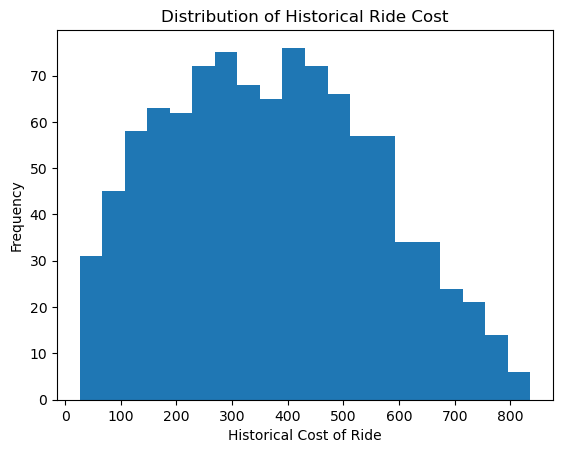

In [17]:
plt.hist(df["Historical_Cost_of_Ride"], bins=20)

plt.title("Distribution of Historical Ride Cost")
plt.xlabel("Historical Cost of Ride")
plt.ylabel("Frequency")
plt.show()

The distribution shows that historical ride costs vary across the dataset. Most ride costs are concentrated in the middle range, while fewer rides have very low or very high costs. This confirms that historical ride cost is important to analyze for dynamic pricing

## Average Ride Cost by Category

Comparing the average historical ride cost across categorical variables to understand which groups have higher or lower ride costs

In [18]:
df.groupby("Vehicle_Type")["Historical_Cost_of_Ride"].mean().round(2)

Vehicle_Type
Economy    346.57
Premium    396.25
Name: Historical_Cost_of_Ride, dtype: float64

In [19]:
df.groupby("Location_Category")["Historical_Cost_of_Ride"].mean().round(2)

Location_Category
Rural       379.94
Suburban    374.32
Urban       363.67
Name: Historical_Cost_of_Ride, dtype: float64

In [20]:
df.groupby("Time_of_Booking")["Historical_Cost_of_Ride"].mean().round(2)

Time_of_Booking
Afternoon    380.82
Evening      364.25
Morning      378.06
Night        367.01
Name: Historical_Cost_of_Ride, dtype: float64

In [21]:
df.groupby("Customer_Loyalty_Status")["Historical_Cost_of_Ride"].mean().round(2)

Customer_Loyalty_Status
Gold       376.12
Regular    380.13
Silver     362.77
Name: Historical_Cost_of_Ride, dtype: float64

The category analysis shows that average historical ride cost changes across different categorical variables. Premium rides have a higher average cost than economy rides. Rural locations show the highest average ride cost compared to suburban and urban locations. Ride costs also vary by time of booking, with afternoon and morning rides showing higher average costs than evening and night rides. Customer loyalty status also shows small differences in average ride cost.

These results suggest that vehicle type, location category, time of booking, and customer loyalty status may be useful pricing factors for the dynamic pricing strategy

## Average Ride Cost by Vehicle Type

Creating a bar chart to compare the average historical ride cost between vehicle types.

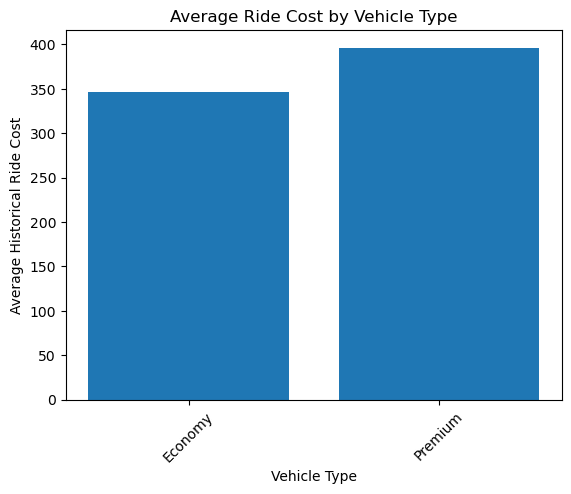

In [26]:
vehicle_cost = df.groupby("Vehicle_Type")["Historical_Cost_of_Ride"].mean().round(2)

plt.bar(vehicle_cost.index, vehicle_cost.values)

plt.title("Average Ride Cost by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Historical Ride Cost")
plt.xticks(rotation=45)
plt.show()

## Average Ride Cost by Location Category

Creating a bar chart to compare the average historical ride cost across location categories

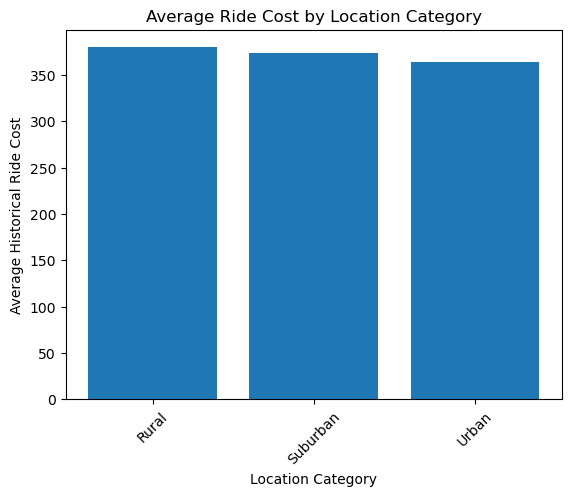

In [27]:
location_cost = df.groupby("Location_Category")["Historical_Cost_of_Ride"].mean().round(2)

plt.bar(location_cost.index, location_cost.values)

plt.title("Average Ride Cost by Location Category")
plt.xlabel("Location Category")
plt.ylabel("Average Historical Ride Cost")
plt.xticks(rotation=45)
plt.show()

## Average Ride Cost by Time of Booking

Creating a bar chart to compare the average historical ride cost across different booking times

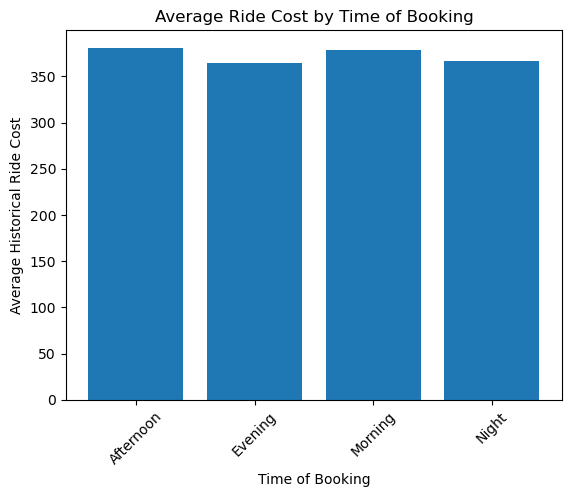

In [28]:
time_cost = df.groupby("Time_of_Booking")["Historical_Cost_of_Ride"].mean().round(2)

plt.bar(time_cost.index, time_cost.values)

plt.title("Average Ride Cost by Time of Booking")
plt.xlabel("Time of Booking")
plt.ylabel("Average Historical Ride Cost")
plt.xticks(rotation=45)
plt.show()

## Average Ride Cost by Customer Loyalty Status

Creating a bar chart to compare the average historical ride cost across customer loyalty groups

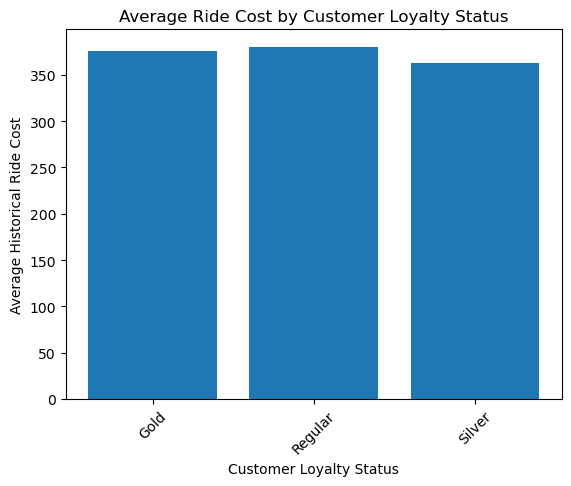

In [29]:
loyalty_cost = df.groupby("Customer_Loyalty_Status")["Historical_Cost_of_Ride"].mean().round(2)

plt.bar(loyalty_cost.index, loyalty_cost.values)

plt.title("Average Ride Cost by Customer Loyalty Status")
plt.xlabel("Customer Loyalty Status")
plt.ylabel("Average Historical Ride Cost")
plt.xticks(rotation=45)
plt.show()

## Demand and Supply Analysis

Analyzing rider demand and driver supply because dynamic pricing can be affected by the balance between how many riders request rides and how many drivers are available

In [30]:
df[["Number_of_Riders", "Number_of_Drivers", "Demand_Supply_Ratio", "Demand_Supply_Difference"]].describe()

,Number_of_Riders,Number_of_Drivers,Demand_Supply_Ratio,Demand_Supply_Difference
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,60.372000,27.076000,3.235461,33.296000
std,23.701506,19.068346,2.533519,18.936869
min,20.000000,5.000000,1.112360,10.000000
25%,40.000000,11.000000,1.658793,18.000000
50%,60.000000,22.000000,2.357143,28.000000
75%,81.000000,38.000000,3.800000,45.250000
max,100.000000,89.000000,17.600000,93.000000


The demand and supply summary shows the range of rider demand and driver availability in the dataset. The demand-supply ratio helps show how many riders there are compared to available drivers, while the demand-supply difference shows the gap between riders and drivers


## Demand-Supply Ratio by Location Category

Comparing the average demand-supply ratio across location categories

In [31]:
location_ratio = df.groupby("Location_Category")["Demand_Supply_Ratio"].mean().round(2)
location_ratio

Location_Category
Rural       3.51
Suburban    3.13
Urban       3.07
Name: Demand_Supply_Ratio, dtype: float64

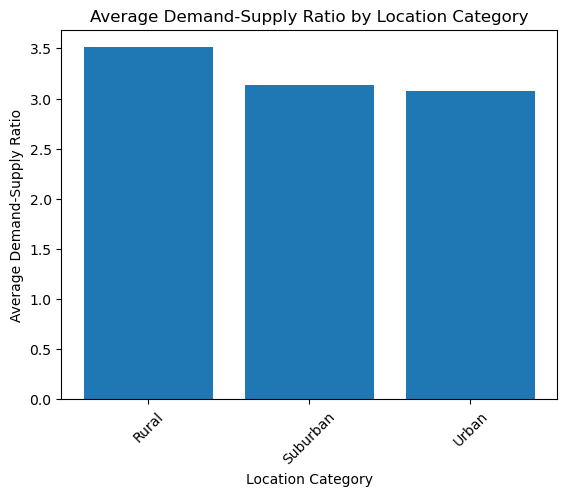

In [32]:
plt.bar(location_ratio.index, location_ratio.values)

plt.title("Average Demand-Supply Ratio by Location Category")
plt.xlabel("Location Category")
plt.ylabel("Average Demand-Supply Ratio")
plt.xticks(rotation=45)
plt.show()

This chart helps show whether some location categories have higher demand compared to driver supply. A higher demand-supply ratio may indicate stronger pricing pressure

## Demand-Supply Ratio by Time of Booking

Comparing the average demand-supply ratio across different booking times

In [33]:
time_ratio = df.groupby("Time_of_Booking")["Demand_Supply_Ratio"].mean().round(2)
time_ratio

Time_of_Booking
Afternoon    3.12
Evening      3.19
Morning      3.19
Night        3.42
Name: Demand_Supply_Ratio, dtype: float64

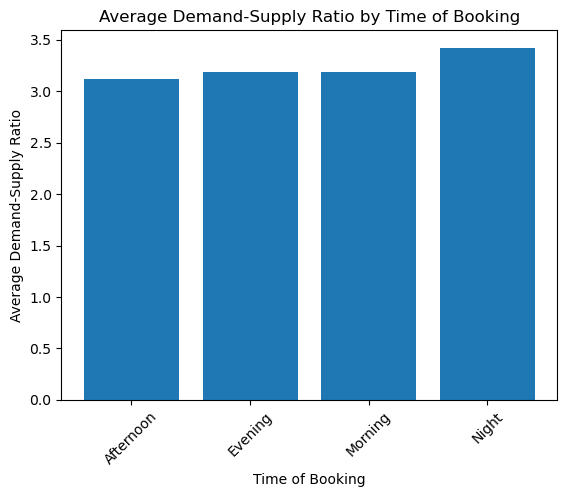

In [34]:
plt.bar(time_ratio.index, time_ratio.values)

plt.title("Average Demand-Supply Ratio by Time of Booking")
plt.xlabel("Time of Booking")
plt.ylabel("Average Demand-Supply Ratio")
plt.xticks(rotation=45)
plt.show()

This chart helps identify whether demand compared to supply changes depending on the time of booking - useful for understanding possible surge-pricing conditions

## Demand-Supply Ratio and Ride Cost

Checking whether higher demand compared to supply is related to higher historical ride cost

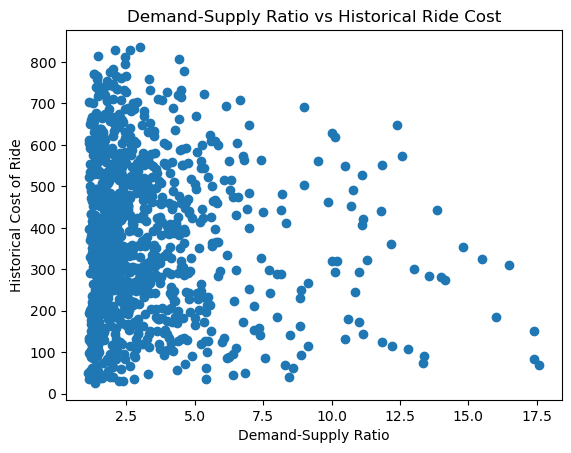

In [35]:
plt.scatter(df["Demand_Supply_Ratio"], df["Historical_Cost_of_Ride"])

plt.title("Demand-Supply Ratio vs Historical Ride Cost")
plt.xlabel("Demand-Supply Ratio")
plt.ylabel("Historical Cost of Ride")
plt.show()

This scatter plot helps show whether rides with a higher demand-supply ratio also tend to have higher historical ride costs. This is important because demand and supply imbalance is one of the main ideas behind dynamic pricing